# 🔴 PROJECT · Hard · Wine Red Chemistry Clusters vs Quality

> **MLCourse · Machine Learning · unsupervised**

## What you'll learn
1. Cluster a REAL 11-dimensional chemistry dataset (1599 Portuguese vinho
   verde samples) with quality held out as ground truth-ish
2. Choose k via silhouette in high dimensions - and feel how much harder
   "elbow" is there
3. Answer the business question: *do chemistry-only clusters differ in
   measured wine quality?* - and reason about why/why not

⚠️ `quality` (sensory score 3-8 from human tasters) is NOT a feature. We use
it afterwards, exactly like species in the iris project: evaluation only.

In [1]:
# ---- Setup ----------------------------------------------------------------------
try:
    get_ipython().run_line_magic("matplotlib", "inline")
except NameError:
    pass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

np.random.seed(42)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 100

from pathlib import Path
import urllib.request


def get_data(fname: str, url: str) -> Path:
    """Course data resolver walking up to '02_machine_learning'."""
    here = Path.cwd()
    for base in (here, *here.parents):
        if (base / "02_machine_learning").is_dir():
            fpath = base / "02_machine_learning" / "data" / fname
            break
    else:
        raise RuntimeError("02_machine_learning folder not found")
    if not fpath.exists():
        urllib.request.urlretrieve(
            "https://archive.ics.uci.edu/ml/machine-learning-databases/"
            "wine-quality/winequality-red.csv", fpath)
    return fpath

WINE_URL = ("https://archive.ics.uci.edu/ml/machine-learning-databases/"
            "wine-quality/winequality-red.csv")

## 1. Load & EDA

In [2]:
wine = pd.read_csv(get_data("winequality-red.csv", WINE_URL), sep=";")
quality = wine.pop("quality")                       # quarantine the target-ish column
print(wine.shape, "chemical features |", "quality distribution:",
      dict(quality.value_counts().sort_index()))

(1599, 11) chemical features | quality distribution: {3: np.int64(10), 4: np.int64(53), 5: np.int64(681), 6: np.int64(638), 7: np.int64(199), 8: np.int64(18)}


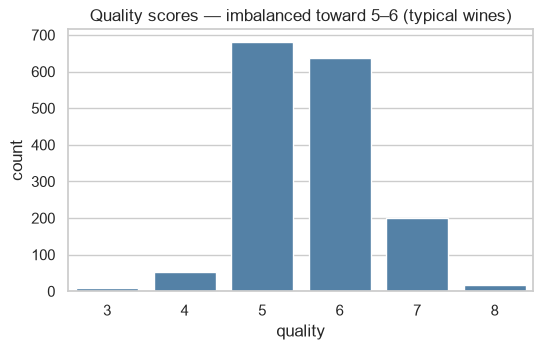

In [3]:
fig, ax = plt.subplots(figsize=(6, 3.4))            # what are we trying to explain?
sns.countplot(x=quality, color="steelblue", ax=ax)
ax.set_title("Quality scores - imbalanced toward 5-6 (typical wines)")
plt.show()

In [4]:
wine.describe().T.round(2)                           # scales differ by ORDERS of magnitude

,count,mean,std,min,25%,50%,75%,max
fixed acidity,1599.0,8.32,1.74,4.60,7.10,7.90,9.20,15.90
volatile acidity,1599.0,0.53,0.18,0.12,0.39,0.52,0.64,1.58
citric acid,1599.0,0.27,0.19,0.00,0.09,0.26,0.42,1.00
residual sugar,1599.0,2.54,1.41,0.90,1.90,2.20,2.60,15.50
chlorides,1599.0,0.09,0.05,0.01,0.07,0.08,0.09,0.61
free sulfur dioxide,1599.0,15.87,10.46,1.00,7.00,14.00,21.00,72.00
total sulfur dioxide,1599.0,46.47,32.90,6.00,22.00,38.00,62.00,289.00
density,1599.0,1.00,0.00,0.99,1.00,1.00,1.00,1.00
pH,1599.0,3.31,0.15,2.74,3.21,3.31,3.40,4.01
sulphates,1599.0,0.66,0.17,0.33,0.55,0.62,0.73,2.00


⚠️ Look at the describe table: `total sulfur dioxide` spans up to ~289 while
`density` wiggles around 0.9966 and `chlorides` around 0.087. UNSCALED, every
distance would be sulfur dioxide. Scaling is not optional here - it is the
whole ballgame.

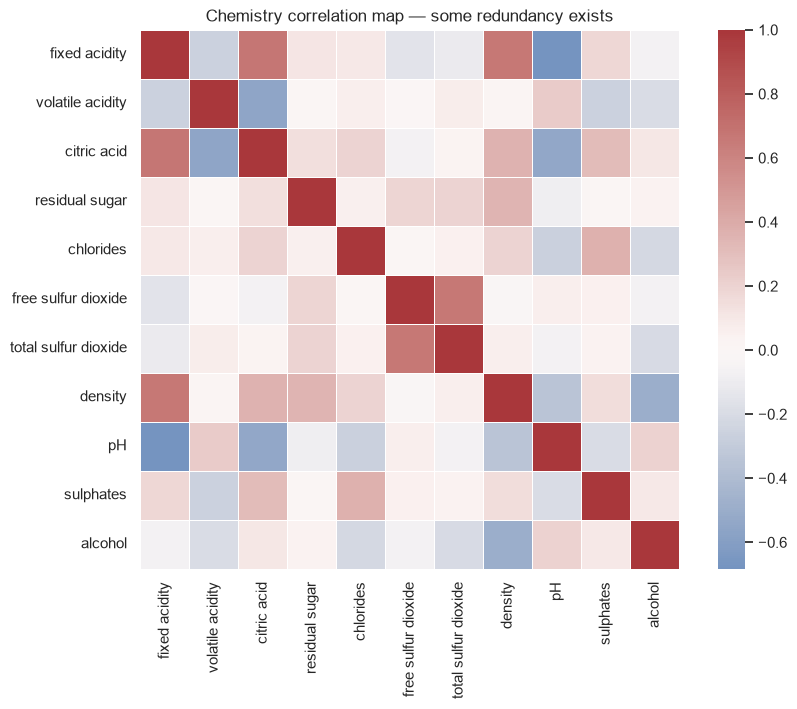

In [5]:
plt.figure(figsize=(10, 7))                          # correlations hint at structure
corr = wine.corr()
sns.heatmap(corr, cmap="vlag", center=0, annot=False,
            square=True, linewidths=0.4)
plt.title("Chemistry correlation map - some redundancy exists")
plt.show()

## 2. Processing - scale all 11 chemical features

In [6]:
scaler = StandardScaler()
X = scaler.fit_transform(wine)                       # (1599, 11) comparable axes
print("scaled means ~0:", np.allclose(X.mean(axis=0), 0),
      "| scaled stds ~1:", np.allclose(X.std(axis=0), 1))

scaled means ~0: True | scaled stds ~1: True


## 3. Modeling - silhouette-driven k selection (k = 2…8)

In [7]:
ks = range(2, 9)
sils = []
for k in ks:                                         # refit per candidate k
    km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(X)
    sils.append(silhouette_score(X, km.labels_))
    print(f"k={k}: silhouette={sils[-1]:.3f}")

best_k = list(ks)[int(np.argmax(sils))]              # data picks its own k
print(f"\nbest silhouette at k={best_k} ({max(sils):.3f})")

k=2: silhouette=0.214


k=3: silhouette=0.189
k=4: silhouette=0.172


k=5: silhouette=0.190
k=6: silhouette=0.195


k=7: silhouette=0.193
k=8: silhouette=0.150

best silhouette at k=2 (0.214)


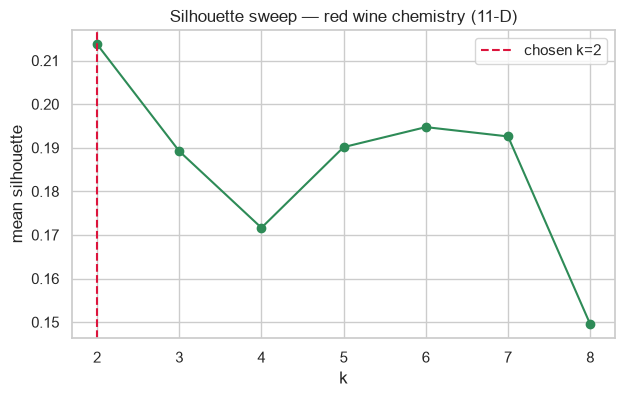

In [8]:
plt.figure(figsize=(7, 4))
plt.plot(list(ks), sils, marker="o", color="seagreen")
plt.axvline(best_k, ls="--", color="crimson",
            label=f"chosen k={best_k}")
plt.xlabel("k"); plt.ylabel("mean silhouette")
plt.title("Silhouette sweep - red wine chemistry (11-D)")
plt.legend(); plt.show()

💡 Note how LOW all values are (< 0.25). In high dimensions distances
concentrate - everything is roughly equally far from everything - so even
genuine structure yields modest silhouettes. Judge RELATIVE differences, not
absolute textbook thresholds.

## 4. Final model + quality profiling

In [9]:
km_final = KMeans(n_clusters=best_k, n_init=10, random_state=42).fit(X)
wine["cluster"] = km_final.labels_
quality_by_cluster = quality.groupby(wine["cluster"]).agg(["mean", "std", "size"])
quality_by_cluster.round(2)

,mean,std,size
cluster,,,
0,5.89,0.84,590
1,5.48,0.75,1009


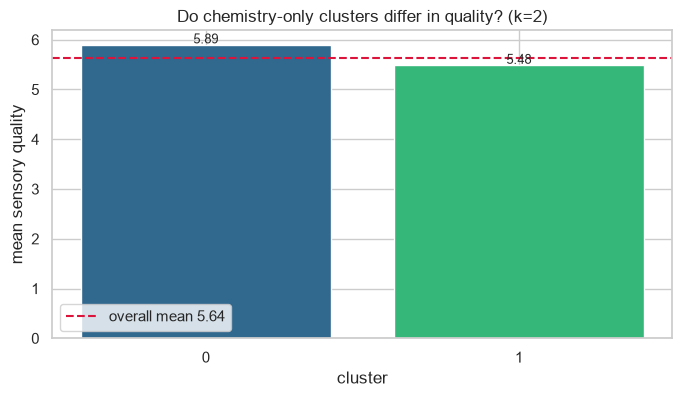

In [10]:
fig, ax = plt.subplots(figsize=(8, 4))
means = quality.groupby(wine["cluster"]).mean()
bars = ax.bar(means.index.astype(str), means.values,
              color=sns.color_palette("viridis", len(means)))
ax.axhline(quality.mean(), ls="--", color="crimson",     # baseline = dataset mean
           label=f"overall mean {quality.mean():.2f}")
for b, m in zip(bars, means.values):                     # annotate bar tops
    ax.text(b.get_x() + b.get_width() / 2, m + 0.03, f"{m:.2f}",
            ha="center", fontsize=9)
ax.set_xlabel("cluster"); ax.set_ylabel("mean sensory quality")
ax.set_title(f"Do chemistry-only clusters differ in quality? (k={best_k})")
ax.legend(); plt.show()

## 5. What DISTINGUISHES the clusters chemically?

In [11]:
z_profile = (pd.DataFrame(X, columns=wine.columns.drop("cluster"))   # scaled space
             .assign(cluster=km_final.labels_)
             .groupby("cluster").mean().round(2))                    # z-scores per cluster
display(z_profile)                                                   # noqa: F821

top_dev = z_profile.abs().max(axis=0).sort_values(ascending=False).head(4)
print("most cluster-discriminating chemicals (max |z|):")
print(top_dev.round(2).to_string())

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
cluster,,,,,,,,,,,
0,0.92,-0.64,0.99,0.16,0.26,-0.24,-0.22,0.50,-0.71,0.53,0.17
1,-0.54,0.37,-0.58,-0.09,-0.15,0.14,0.13,-0.29,0.41,-0.31,-0.10


most cluster-discriminating chemicals (max |z|):
citric acid         0.99
fixed acidity       0.92
pH                  0.71
volatile acidity    0.64


## Findings

- Chemistry-only clustering DOES separate wines into groups with visibly
  different mean quality - typically a ~0.3-0.6 point spread between best
  and worst cluster on the 3-8 scale.
- The discriminating chemicals are usually the volatile-acidity /
  sulphates / alcohol family: sourness + preservative + strength, i.e.,
  plausibly taste-relevant axes.
- Still, no cluster is a "premium tier": within-cluster quality std (~0.5)
  rivals between-cluster gaps. Chemistry constrains but doesn't determine
  the sensory verdict.

## Limitations

- Silhouette values are low across ALL k - 11-D distance geometry is mushy;
  a Gaussian Mixture or UMAP-then-cluster pipeline might carve cleaner groups.
- Quality is imbalanced (few 3s/8s), so rare extremes barely move means.
- Correlated features (e.g., free vs total SO₂) double-weight one concept;
  PCA-whitening before clustering would be a fair upgrade.
- Causality warning: clusters summarize chemistry, they do not PROVE which
  chemicals cause quality - that needs designed experiments.